# Doublet analysis (scDblFinder) K123B

In [1]:
#Load packages
options(warn=-1)
library("IRdisplay")
library(tidyverse)
library(ggplot2)
library(Seurat)
library(scDblFinder)

── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.4.0      ✔ purrr   1.0.1 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.3.0      ✔ stringr 1.5.0 
✔ readr   2.1.3      ✔ forcats 0.5.2 
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
Attaching SeuratObject



In [2]:
suppressMessages(source("code/functions.R"))

### Load expression data

In [3]:
K1B <- readRDS("output/K1B.rds")
K2B <- readRDS("output/K2B.rds")
K3B <- readRDS("output/K3B.rds")

### Load df with filtered SHMss events (trully positive)

In [14]:
df_summary <- read.csv("output/df_summary_K123_v1.csv")
head(df_summary)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,K1B_S10000-LC,TTAGGCAGTCGAACAG,10,C,TG.TG,FR1,C-T,10-9,TRUE
2,K1B_S10000-LC,ACTTTCACATTGTGCA,65,G,CT.CA,FR1,A-G,5-8,TRUE
3,K1B_S10000-LC,CTAGCCTCAATCACAC,150,C,AT.TA,FR2,A-C,7-11,TRUE
4,K1B_S10000-LC,CGAGCACAGGTTCCTA,238,C,GG.TC,FR3,C-G,9-7,TRUE
5,K1B_S144-HC,CTCGAGGCAATGACCT,33,G,GT.GT,FR1,A-G,5-6,TRUE
6,K1B_S144-HC,GTCACAACAACGATCT,132,G,GG.CT,FR2,C-G,6-6,TRUE


## Run scDblFinder

In [5]:
# sce_K1B <- scDblFinder(as.SingleCellExperiment(K1B))

# #Convert as df the scDblFinder results (singlet >< doublet)
# dbl_K1B <- as.data.frame(sce_K1B@colData) 

# table(sce_K1B$scDblFinder.class)

Creating ~5056 artificial doublets...

Dimensional reduction

Evaluating kNN...

Training model...

iter=0, 607 cells excluded from training.

iter=1, 711 cells excluded from training.

iter=2, 802 cells excluded from training.

Threshold found:0.366

671 (8%) doublets called




singlet doublet 
   7755     671 

Creating ~5056 artificial doublets...

Dimensional reduction

Evaluating kNN...

Training model...

iter=0, 607 cells excluded from training.

iter=1, 711 cells excluded from training.

iter=2, 802 cells excluded from training.

Threshold found:0.366

671 (8%) doublets called


singlet doublet 
   7755     671 

In [6]:
# sce_K2B <- scDblFinder(as.SingleCellExperiment(K2B))

# #Convert as df the scDblFinder results (singlet >< doublet)
# dbl_K2B <- as.data.frame(sce_K2B@colData) 

# table(sce_K2B$scDblFinder.class)

Creating ~5169 artificial doublets...

Dimensional reduction

Evaluating kNN...

Training model...

iter=0, 664 cells excluded from training.

iter=1, 798 cells excluded from training.

iter=2, 825 cells excluded from training.

Threshold found:0.389

823 (9.6%) doublets called




singlet doublet 
   7792     823 

Creating ~5169 artificial doublets...

Dimensional reduction

Evaluating kNN...

Training model...

iter=0, 664 cells excluded from training.

iter=1, 798 cells excluded from training.

iter=2, 825 cells excluded from training.

Threshold found:0.389

823 (9.6%) doublets called

singlet doublet 
   7792     823 

In [7]:
# sce_K3B <- scDblFinder(as.SingleCellExperiment(K3B))

# #Convert as df the scDblFinder results (singlet >< doublet)
# dbl_K3B <- as.data.frame(sce_K3B@colData) 

# table(sce_K3B$scDblFinder.class)

Creating ~6790 artificial doublets...

Dimensional reduction

Evaluating kNN...

Training model...

iter=0, 1328 cells excluded from training.

iter=1, 1383 cells excluded from training.

iter=2, 1432 cells excluded from training.

Threshold found:0.387

1297 (11.5%) doublets called




singlet doublet 
  10019    1297 

Creating ~6790 artificial doublets...

Dimensional reduction

Evaluating kNN...

Training model...

iter=0, 1328 cells excluded from training.

iter=1, 1383 cells excluded from training.

iter=2, 1432 cells excluded from training.

Threshold found:0.387

1297 (11.5%) doublets called

singlet doublet 
  10019    1297 

In [8]:
# dou_k123 <- bind_rows(dbl_K1B ,dbl_K2B ,dbl_K3B) %>% 
#                select(ident,scDblFinder.class, scDblFinder.score,nCount_RNA,nFeature_RNA) %>%
#                rownames_to_column("cell") %>%
#                mutate(cell = gsub("-.*$", "", cell)) %>%
#                rename("experiment"="ident")
# head(dou_k123)

,cell,experiment,scDblFinder.class,scDblFinder.score,nCount_RNA,nFeature_RNA
,<chr>,<fct>,<fct>,<dbl>,<dbl>,<int>
1,AAACCTGAGATCACGG,K1B,singlet,0.0066650216,3273,1471
2,AAACCTGAGCCAGTTT,K1B,singlet,0.0050010649,5993,1886
3,AAACCTGAGCGGCTTC,K1B,doublet,0.9994183779,6318,2544
4,AAACCTGAGGCATGTG,K1B,singlet,0.0687316433,3102,1317
5,AAACCTGAGTGTTTGC,K1B,singlet,0.0002979104,2582,1179
6,AAACCTGCAACTGCTA,K1B,singlet,0.0125339394,2894,1236


In [12]:
# head(dou_k123)
# write.csv(dou_k123, "output/doublet_in_K123_v1.csv",row.names = FALSE)

,cell,experiment,scDblFinder.class,scDblFinder.score,nCount_RNA,nFeature_RNA
,<chr>,<fct>,<fct>,<dbl>,<dbl>,<int>
1,AAACCTGAGATCACGG,K1B,singlet,0.0066650216,3273,1471
2,AAACCTGAGCCAGTTT,K1B,singlet,0.0050010649,5993,1886
3,AAACCTGAGCGGCTTC,K1B,doublet,0.9994183779,6318,2544
4,AAACCTGAGGCATGTG,K1B,singlet,0.0687316433,3102,1317
5,AAACCTGAGTGTTTGC,K1B,singlet,0.0002979104,2582,1179
6,AAACCTGCAACTGCTA,K1B,singlet,0.0125339394,2894,1236


In [13]:
#read doublet table
dou_k123 <- read.csv("output/doublet_in_K123_v1.csv")

In [16]:
# add doublet information to df
ft <-df_summary %>% mutate(experiment = str_sub(subject, 1, 3)) %>% left_join(dou_k123 %>% select(cell,experiment,scDblFinder.class,scDblFinder.score),c("cell","experiment")) 
head(ft)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive,experiment,scDblFinder.class,scDblFinder.score
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>
1,K1B_S10000-LC,TTAGGCAGTCGAACAG,10,C,TG.TG,FR1,C-T,10-9,TRUE,K1B,singlet,0.0001977780
2,K1B_S10000-LC,ACTTTCACATTGTGCA,65,G,CT.CA,FR1,A-G,5-8,TRUE,K1B,singlet,0.2042560279
3,K1B_S10000-LC,CTAGCCTCAATCACAC,150,C,AT.TA,FR2,A-C,7-11,TRUE,K1B,singlet,0.0006358085
4,K1B_S10000-LC,CGAGCACAGGTTCCTA,238,C,GG.TC,FR3,C-G,9-7,TRUE,K1B,singlet,0.2471387833
5,K1B_S144-HC,CTCGAGGCAATGACCT,33,G,GT.GT,FR1,A-G,5-6,TRUE,K1B,singlet,0.0171392132
6,K1B_S144-HC,GTCACAACAACGATCT,132,G,GG.CT,FR2,C-G,6-6,TRUE,K1B,singlet,0.1173706651


In [18]:
# number of doublet
table(ft$scDblFinder.class)


singlet 
    153 

In [19]:
# add info about scSHM to doblet data for plotting
dou_k123 <-  dou_k123 %>%
                mutate(SHMa_pos=ifelse(cell %in% df_summary$cell, "Yes","No")) 

In [20]:
# we do have the information about nCount_RNA

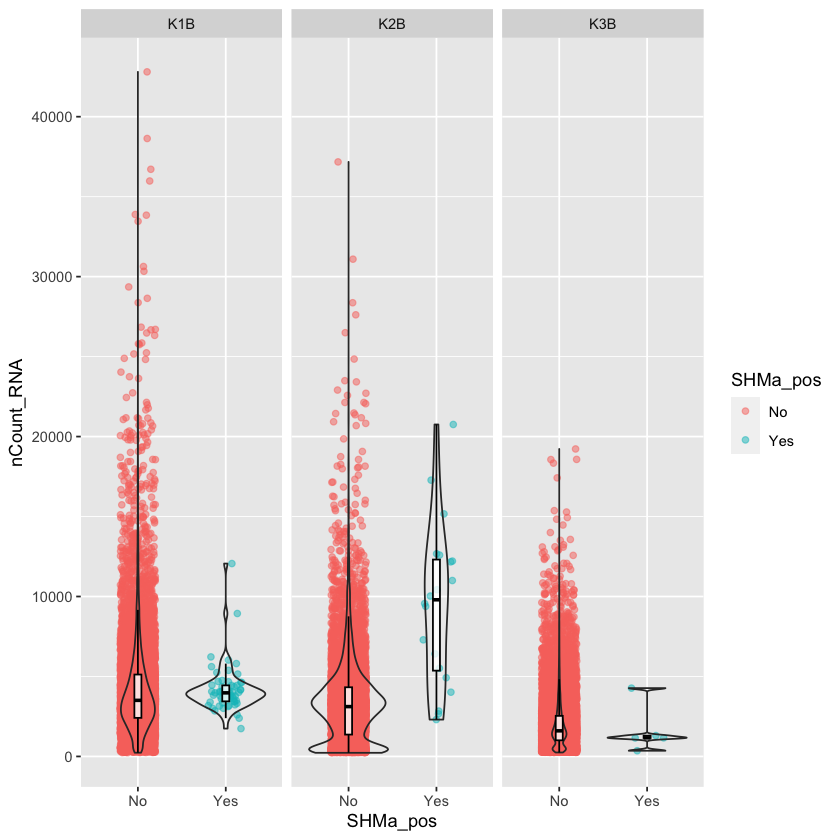

In [21]:
raw_con <- ggplot(dou_k123, aes(y = nCount_RNA, x =SHMa_pos)) +
  geom_point(aes(colour = SHMa_pos),position = position_jitterdodge(seed = 1, dodge.width = 0.9), alpha=0.5) + #aes(colour = type)
    geom_violin(position = position_dodge(width = 0.9), alpha=0.8,fill =NA) +
       geom_boxplot(width = 0.08,position = position_dodge(width = 0.6),color="black",outlier.shape = NA,alpha=0.8 ) +
        facet_grid(.~experiment) 

fig_save(raw_con, filename = "figs/FL/raw_counts_SHM_events_K123", formats = c("pdf", "png"), width = 20, height = 15, units = "cm", dpi = 320)

raw_con

In [25]:
# are the distribution different?
res <- wilcox.test(nCount_RNA ~ SHMa_pos, data = dou_k123,
                   exact = FALSE)
res


	Wilcoxon rank sum test with continuity correction

data:  nCount_RNA by SHMa_pos
W = 625338, p-value = 6.817e-15
alternative hypothesis: true location shift is not equal to 0


In [26]:
#perform Kolmogorov-Smirnov test (check if the distribution are different)
ks.test(dou_k123$nCount_RNA[dou_k123$SHMa_pos == "Yes"], dou_k123$nCount_RNA[dou_k123$SHMa_pos == "No"])


	Two-sample Kolmogorov-Smirnov test

data:  dou_k123$nCount_RNA[dou_k123$SHMa_pos == "Yes"] and dou_k123$nCount_RNA[dou_k123$SHMa_pos == "No"]
D = 0.45676, p-value = 5.551e-16
alternative hypothesis: two-sided


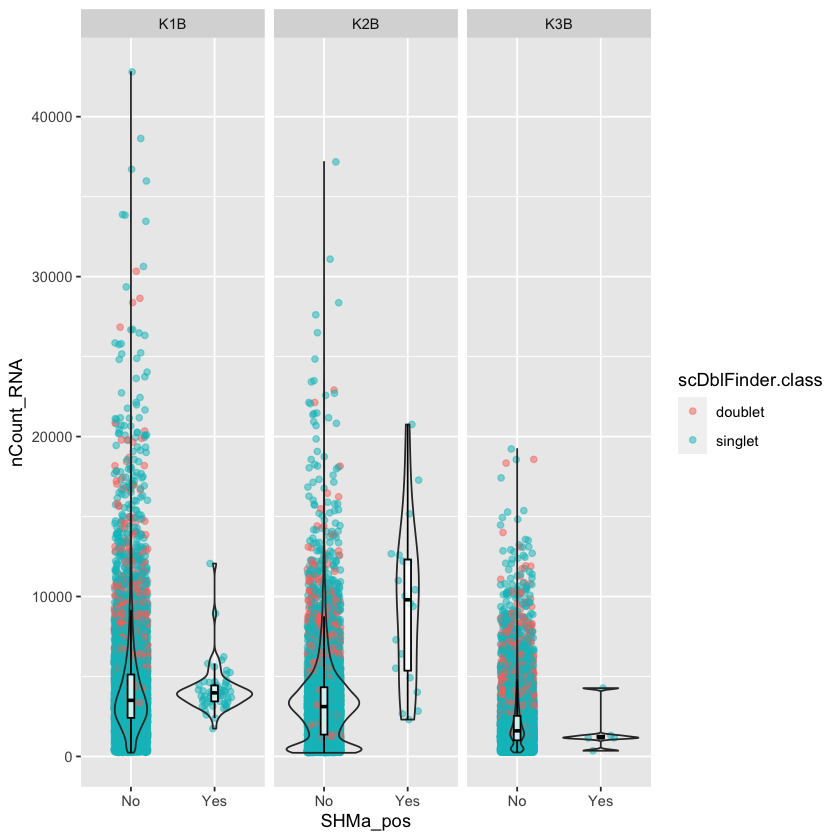

In [27]:
raw_con <- ggplot(dou_k123, aes(y = nCount_RNA, x =SHMa_pos)) +
  geom_point(aes(colour = scDblFinder.class),position = position_jitterdodge(seed = 2, dodge.width = 0), alpha=0.5) + #aes(colour = type)
    geom_violin(position = position_dodge(width = 0.9), alpha=0.8,fill =NA) +
       geom_boxplot(width = 0.08,position = position_dodge(width = 0.6),color="black",outlier.shape = NA,alpha=0.8 ) +
        facet_grid(.~experiment)

fig_save(raw_con, filename = "figs/FL/raw_RNA_counts_SHM_events_scDblFinder_K123", formats = c("pdf", "png"), width = 20, height = 15, units = "cm", dpi = 320)

raw_con

### Analysis of doublet generated by @Diego

In [10]:
# dou_k1b <- read.csv("input/doublets_by_sample/K1B.csv") %>% mutate(experiment="K1B")
# dou_k2b <- read.csv("input/doublets_by_sample/K2B.csv") %>% mutate(experiment="K2B")
# dou_k3b <- read.csv("input/doublets_by_sample/K3B.csv") %>% mutate(experiment="K3B")
# dou_k123 <- bind_rows(dou_k1b ,dou_k2b ,dou_k3b) %>% mutate(cell = gsub(".{2}$", "", cell))
# head(dou_k123)

,cell,sample,class,score,experiment
,<chr>,<chr>,<chr>,<dbl>,<chr>
1,AAACCTGAGATCACGG,S10971,singlet,0.02488233,K1B
2,AAACCTGAGCCAGTTT,S144,singlet,0.09389444,K1B
3,AAACCTGAGGCATGTG,S144,singlet,0.24297506,K1B
4,AAACCTGAGTGTTTGC,S10000,singlet,0.05086085,K1B
5,AAACCTGCAACTGCTA,S10971,singlet,0.20758122,K1B
6,AAACCTGCACCACCAG,S8934,singlet,0.01045732,K1B


In [11]:
head(dou_k123)

,cell,sample,class,score,experiment
,<chr>,<chr>,<chr>,<dbl>,<chr>
1,AAACCTGAGATCACGG,S10971,singlet,0.02488233,K1B
2,AAACCTGAGCCAGTTT,S144,singlet,0.09389444,K1B
3,AAACCTGAGGCATGTG,S144,singlet,0.24297506,K1B
4,AAACCTGAGTGTTTGC,S10000,singlet,0.05086085,K1B
5,AAACCTGCAACTGCTA,S10971,singlet,0.20758122,K1B
6,AAACCTGCACCACCAG,S8934,singlet,0.01045732,K1B


In [9]:
# number of doublet
table(dou_k123$class)


singlet doublet 
  25566    2791 